## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('data/stud.csv')

In [3]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Dataset information


- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

In [4]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

##There are no missing values

In [5]:
df.duplicated().sum()

np.int64(0)

##there are no duplicate values

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [8]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### EDA

In [9]:
print("Categories in 'gender variable' :   ", end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' :   ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' :   ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' :   ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test_preparation_course' :   ", end=" ")
print(df['test_preparation_course'].unique())





Categories in 'gender variable' :    <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' :    <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' :    <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' :    <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test_preparation_course' :    <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [12]:


num_features = df.select_dtypes(include='number').columns

print("No. of Numerical Features:", len(num_features))


No. of Numerical Features: 3


In [13]:
cat_features = df.select_dtypes(exclude='number').columns

print('No. of Categorical Features are:', len(cat_features))


No. of Categorical Features are: 5


In [14]:
##print cols
print('We have {} numerical features : {}'.format(len(num_features),num_features))
print('\nwe have {} categorical features : {}'.format(len(cat_features), cat_features))

We have 3 numerical features : Index(['math_score', 'reading_score', 'writing_score'], dtype='str')

we have 5 categorical features : Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


## Adding col for "total score and "average"

In [16]:
df["Total Score"] = df['math_score']+df['reading_score']+ df['writing_score']
df['Average'] = df['Total Score']/3

In [17]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
reading_full = df[df['reading_score']== 100]['Average'].count()
writting_full = df[df['writing_score'] == 100]['Average'].count()
math_full = df[df['math_score'] == 100]['Average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Reading: {reading_full}')
print(f'Number of students with full marks in Writing: {writting_full}')



Number of students with full marks in Maths: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


In [23]:
reading_less_20 = df[df['reading_score']<= 20]['Average'].count()
writting_less_20 = df[df['writing_score'] <= 20]['Average'].count()
math_less_20 = df[df['math_score'] <= 20]['Average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 in Reading: {reading_less_20}')
print(f'Number of students with less than 20 in Writing: {writting_less_20}')



Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 in Reading: 1
Number of students with less than 20 in Writing: 3


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

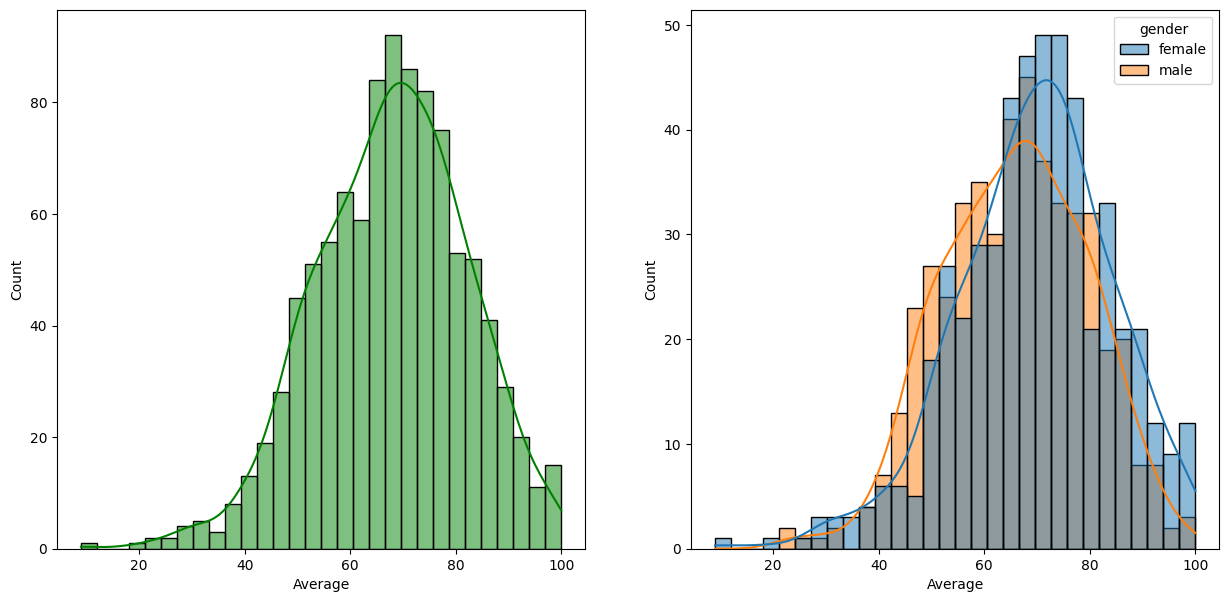

In [27]:
fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=30, kde= True, color='g' )
plt.subplot(122)
sns.histplot(data=df,x='Average',bins=30, kde= True, hue='gender')
plt.show()

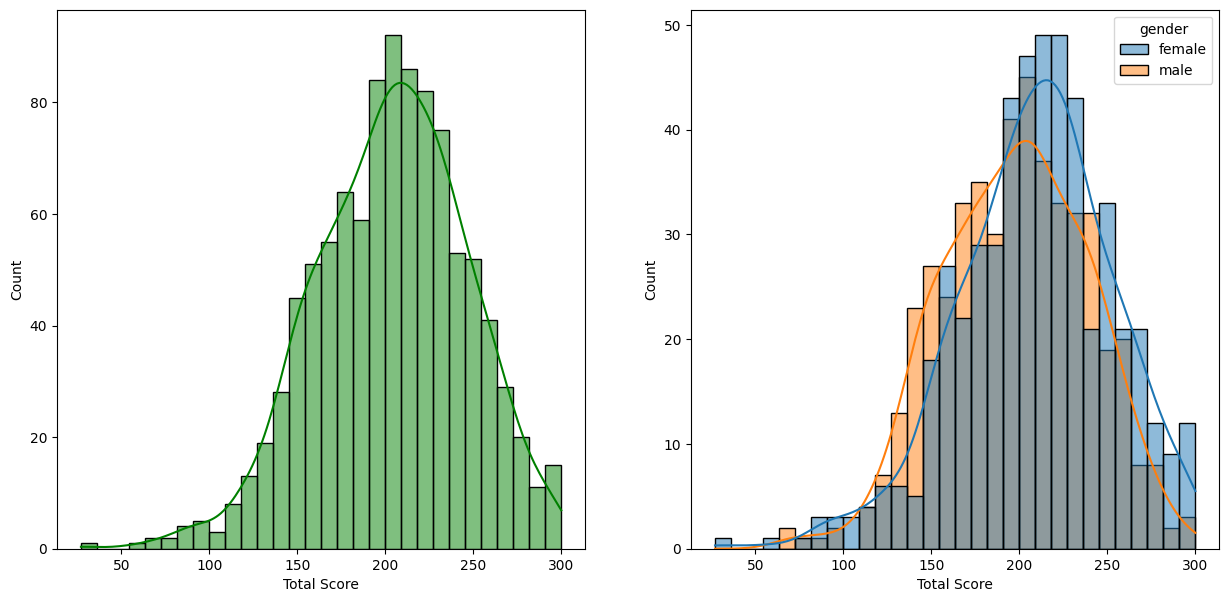

In [28]:
fig, axs = plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins=30, kde= True, color='g' )
plt.subplot(122)
sns.histplot(data=df,x='Total Score',bins=30, kde= True, hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

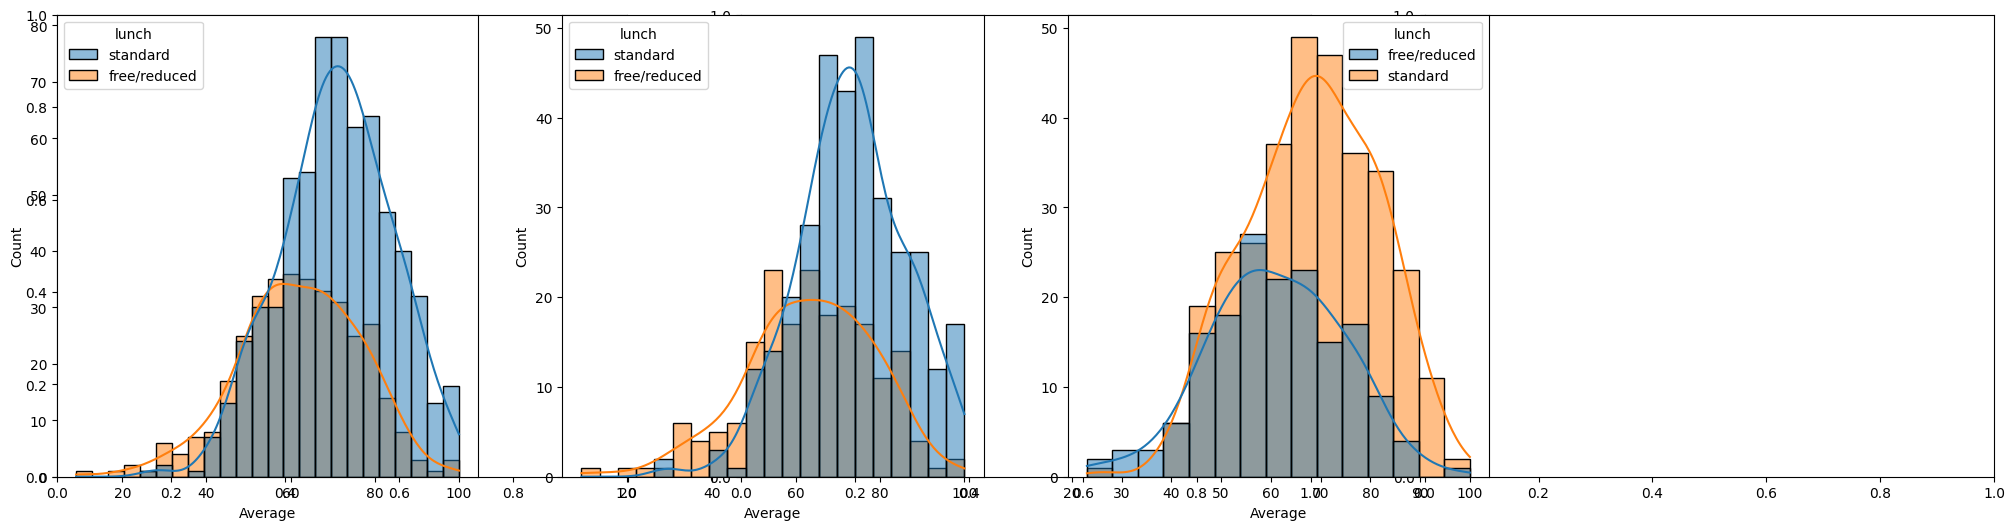

In [30]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data= df, x = 'Average',kde =True, hue = 'lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

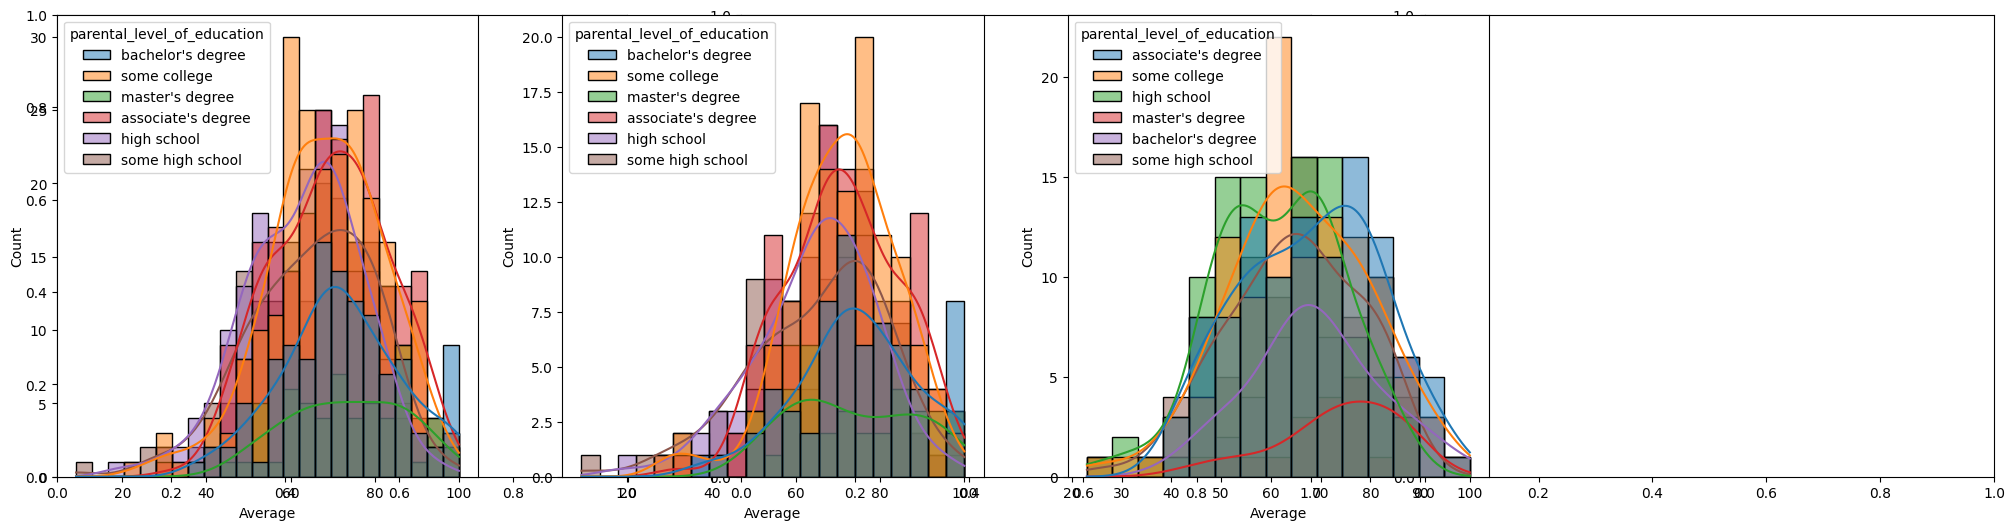

In [33]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data= df, x = 'Average',kde =True, hue = 'parental_level_of_education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

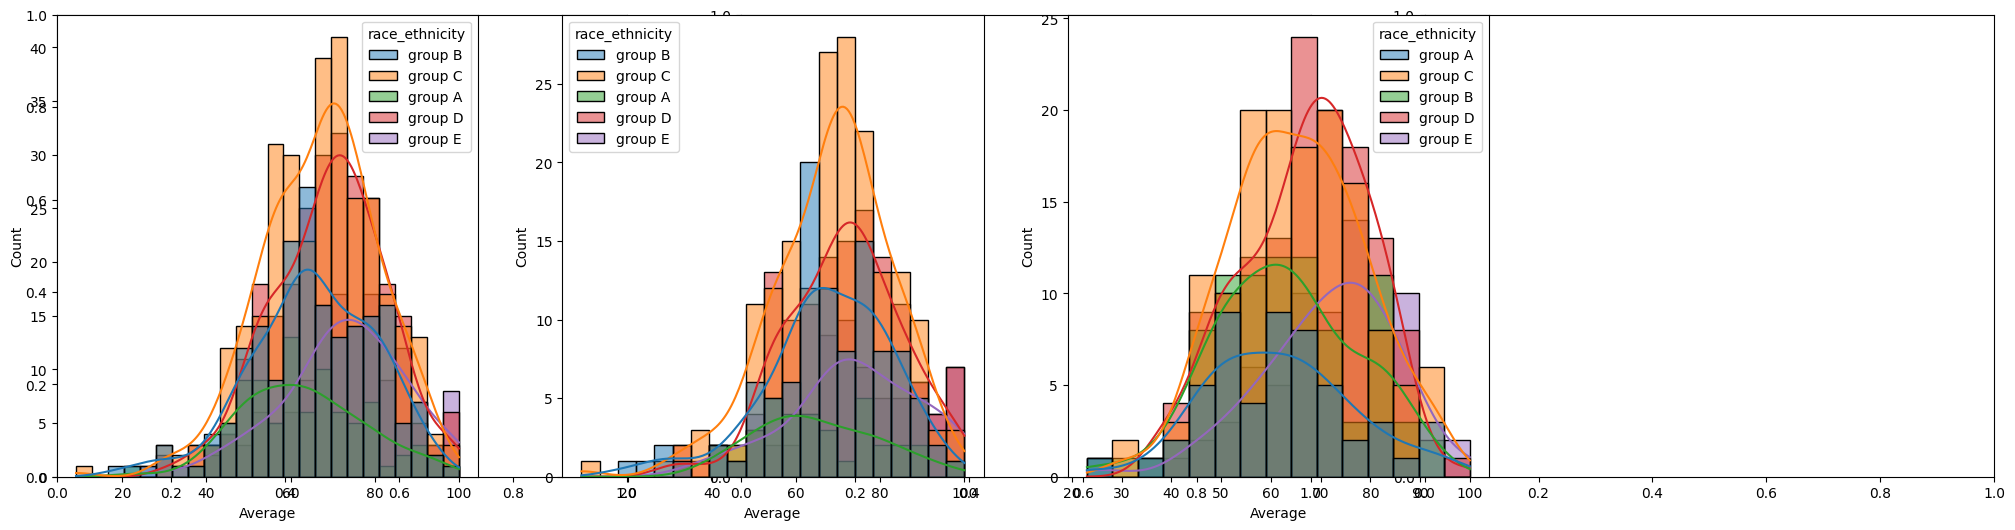

In [34]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data= df, x = 'Average',kde =True, hue = 'race_ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='race_ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='race_ethnicity')
plt.show()

#####  Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

<Axes: title={'center': 'WRITING SCORES'}, ylabel='writing_score'>

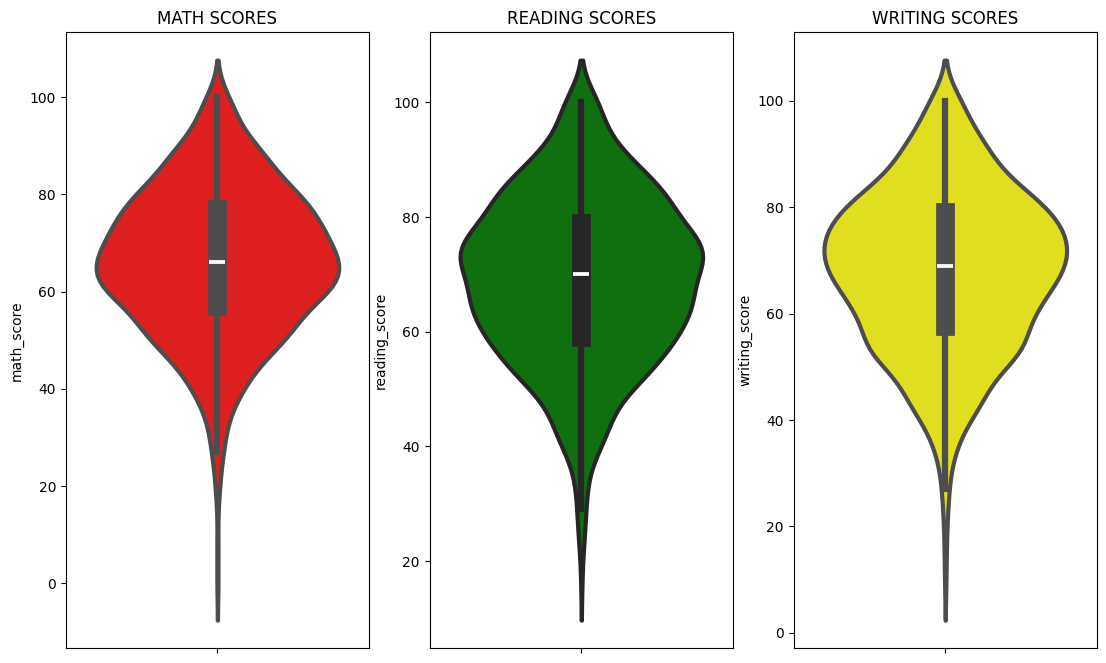

In [38]:
plt.figure(figsize=(18,8))
plt.subplot(141)
plt.title("MATH SCORES")
sns.violinplot(data=df, y = 'math_score',color='red',linewidth=3)
plt.subplot(142)
plt.title("READING SCORES")
sns.violinplot(data=df, y = 'reading_score',color='green',linewidth=3)
plt.subplot(143)
plt.title("WRITING SCORES")
sns.violinplot(data=df, y = 'writing_score',color='yellow',linewidth=3)

#### Insights
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

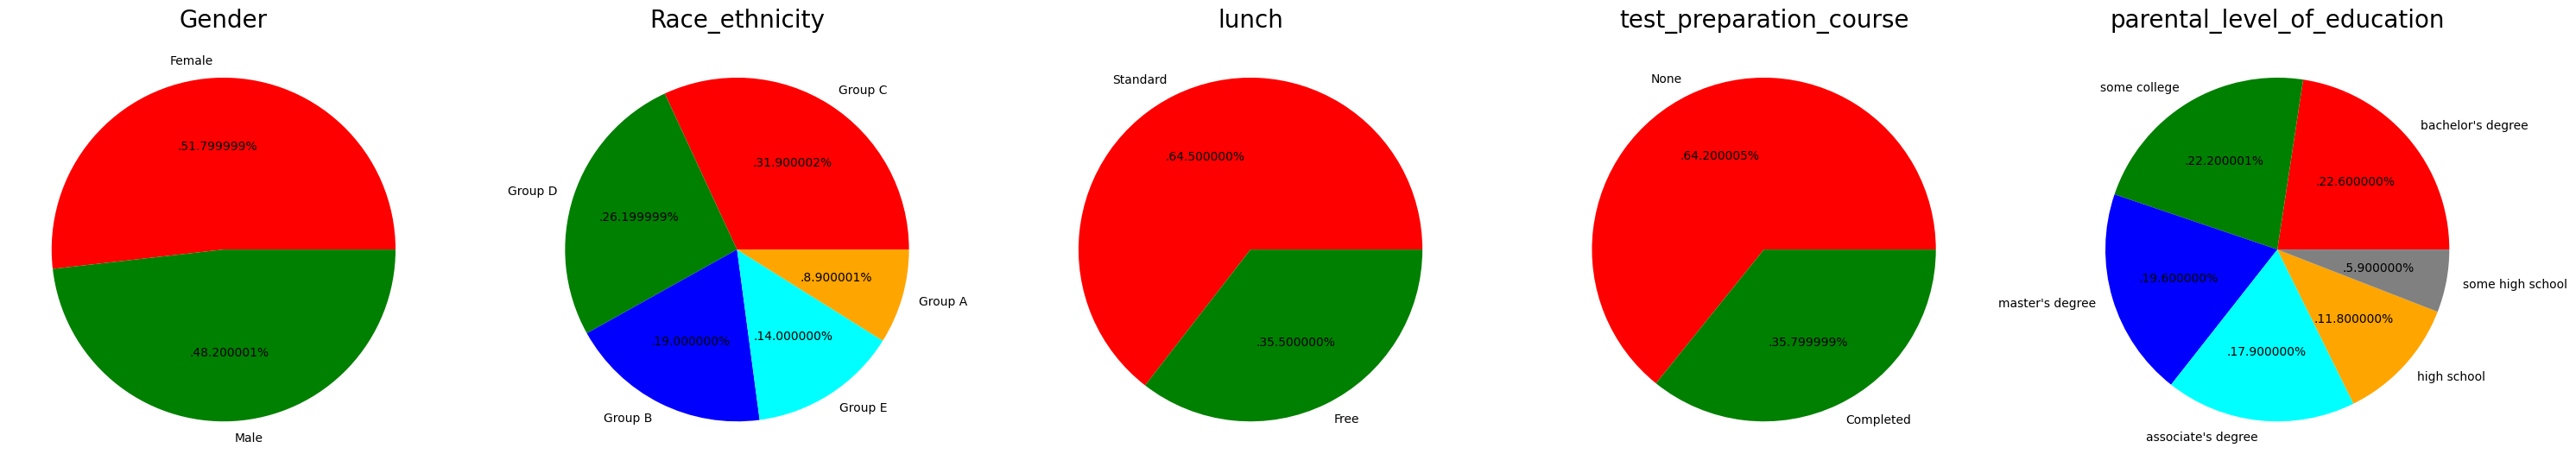

In [44]:
plt.rcParams['figure.figsize'] = (30,30)

#gender
plt.subplot(1,5,1)
size = df['gender'].value_counts()
labels = 'Female','Male'
color = ['red','green']

plt.pie(size, colors=color,labels=labels,autopct='.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

#race_ethnicity
plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels= 'Group C','Group D','Group B','Group E','Group A'
color = ['red','green','blue','cyan','orange']

plt.pie(size,colors=color, labels=labels,autopct='.%2f%%')
plt.title('Race_ethnicity', fontsize = 20)
plt.axis('off')

#lunch

plt.subplot(1,5,3)
size = df['lunch'].value_counts()
labels= 'Standard','Free'
color = ['red','green']

plt.pie(size,colors=color, labels=labels,autopct='.%2f%%')
plt.title('lunch', fontsize = 20)
plt.axis('off')

# test_preparation_course
plt.subplot(1,5,4)
size = df['test_preparation_course'].value_counts()
labels= 'None','Completed'
color = ['red','green']

plt.pie(size,colors=color, labels=labels,autopct='.%2f%%')
plt.title('test_preparation_course', fontsize = 20)
plt.axis('off')

##parental_level_of_education
plt.subplot(1,5,5)
size = df['parental_level_of_education'].value_counts()
labels=  "bachelor's degree",'some college',"master's degree","associate's degree",'high school','some high school'
color = ['red','green','blue','cyan','orange','grey']

plt.pie(size,colors=color, labels=labels,autopct='.%2f%%')
plt.title('parental_level_of_education', fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

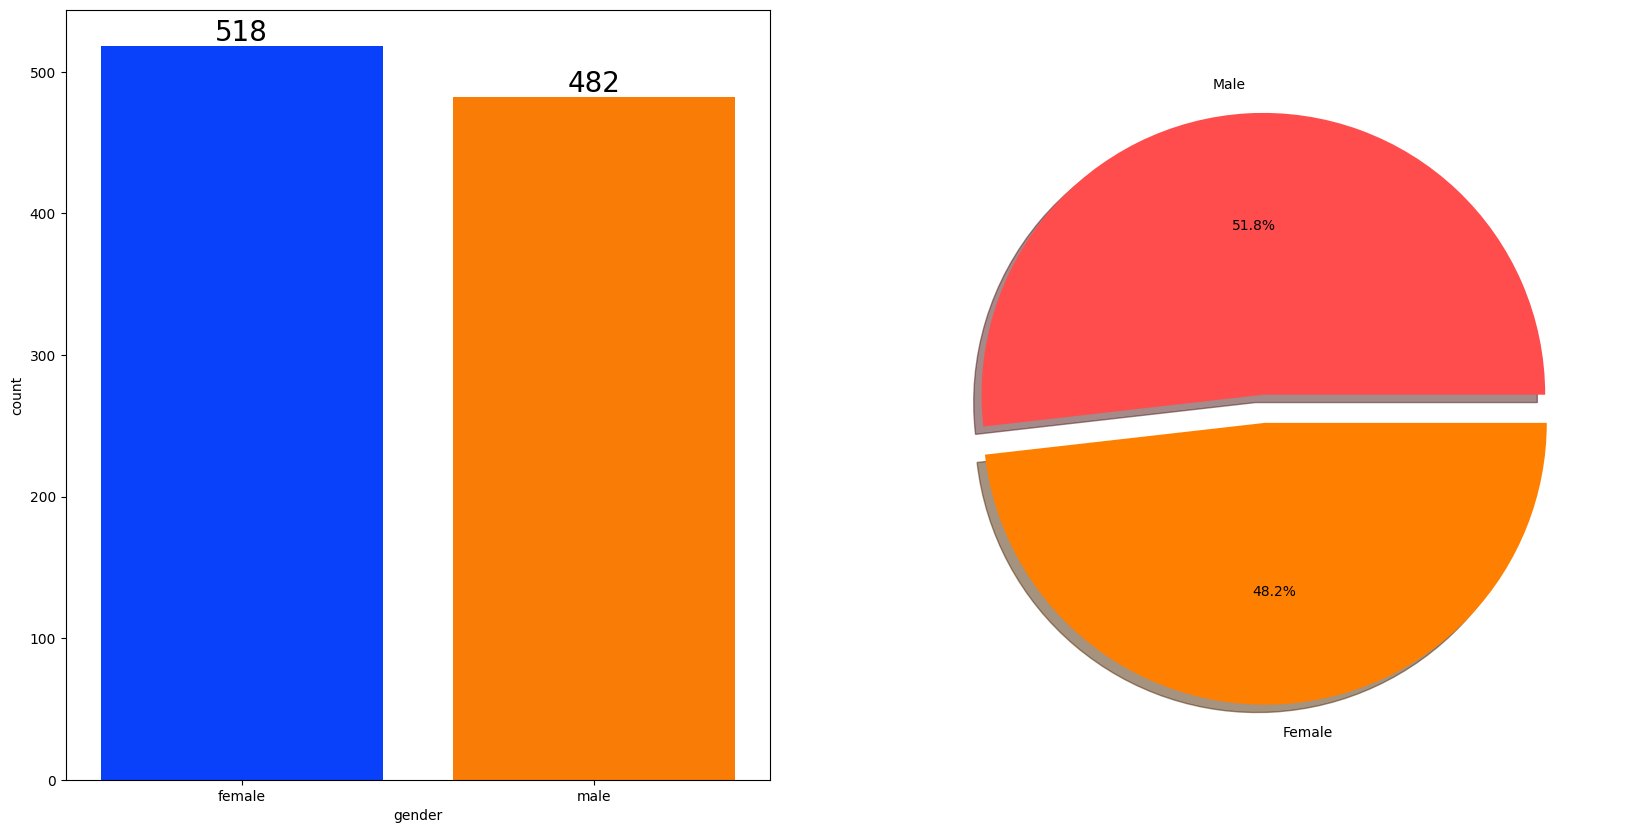

In [49]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

In [55]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group


,math_score,reading_score,writing_score,Total Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


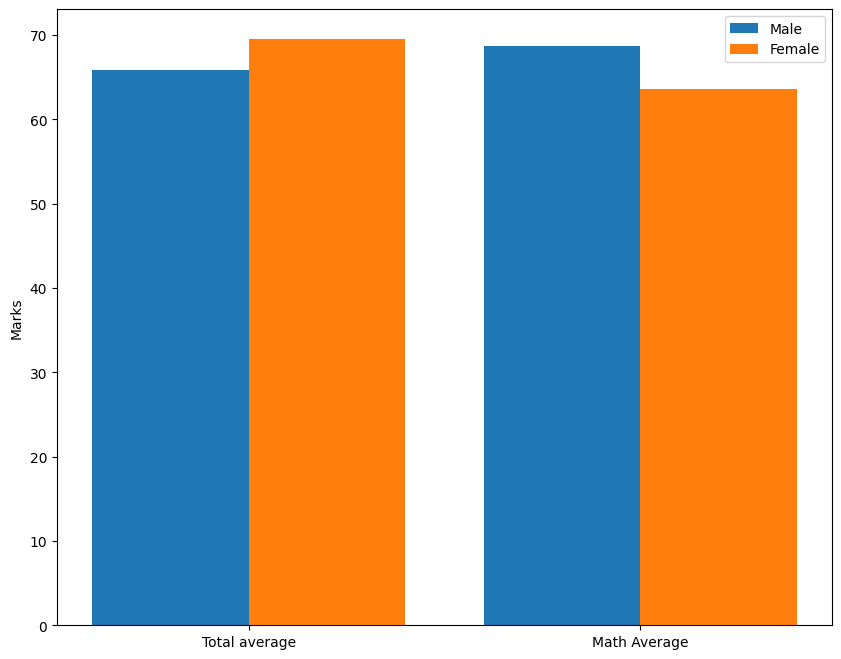

In [60]:
plt.figure(figsize=(10,8))
X =['Total average','Math Average']

female_scores = [gender_group['Average'].iloc[0],gender_group['math_score'].iloc[0]]
male_scores = [gender_group['Average'].iloc[1],gender_group['math_score'].iloc[1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.legend("Total average v/s math avg marks of both the genders")
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

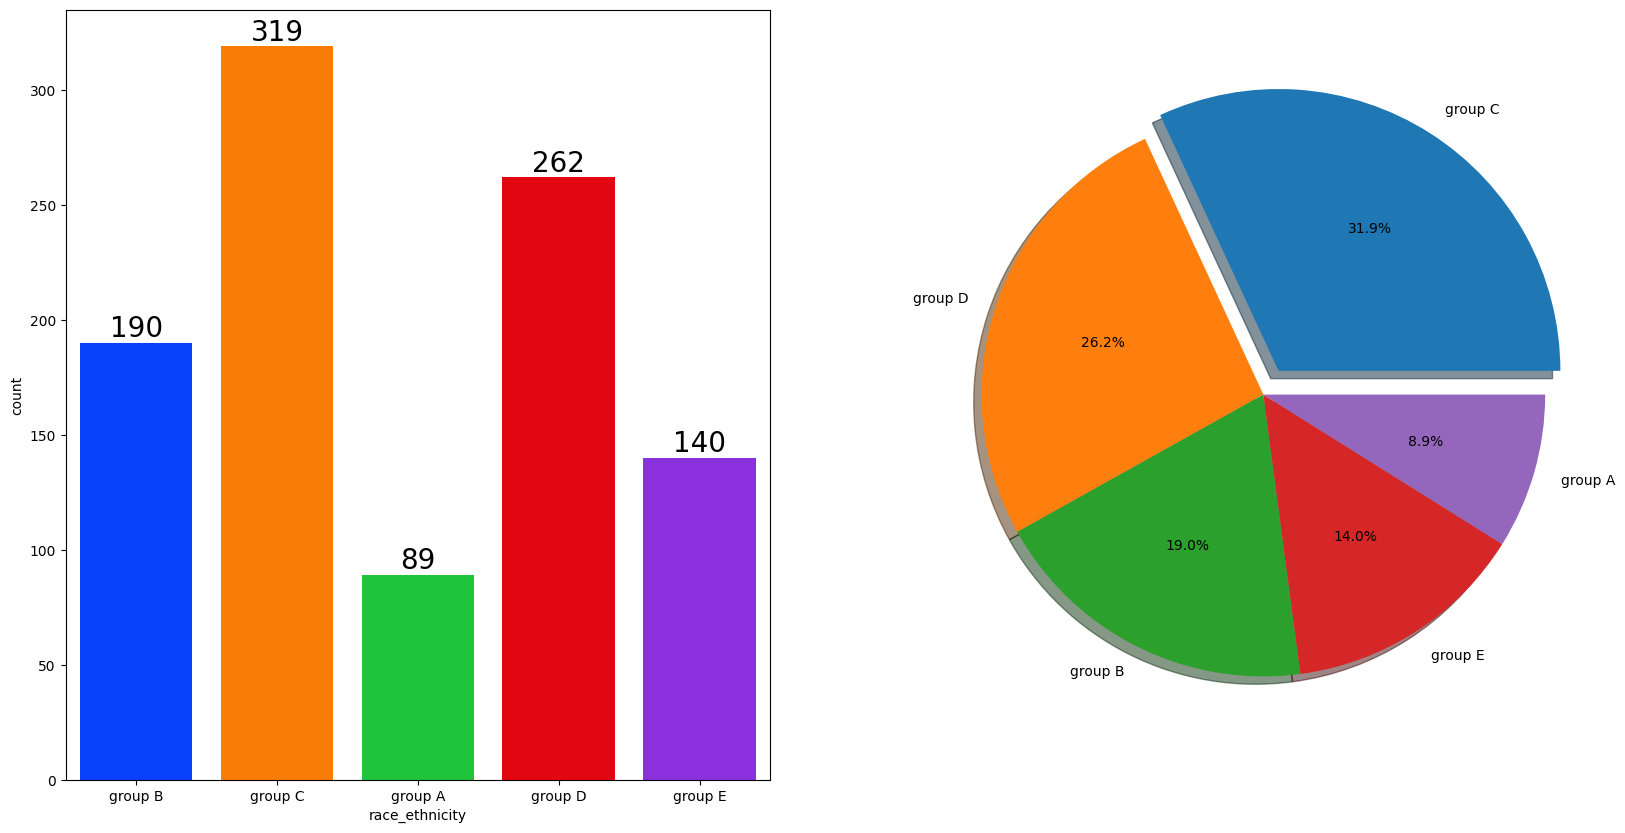

In [61]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

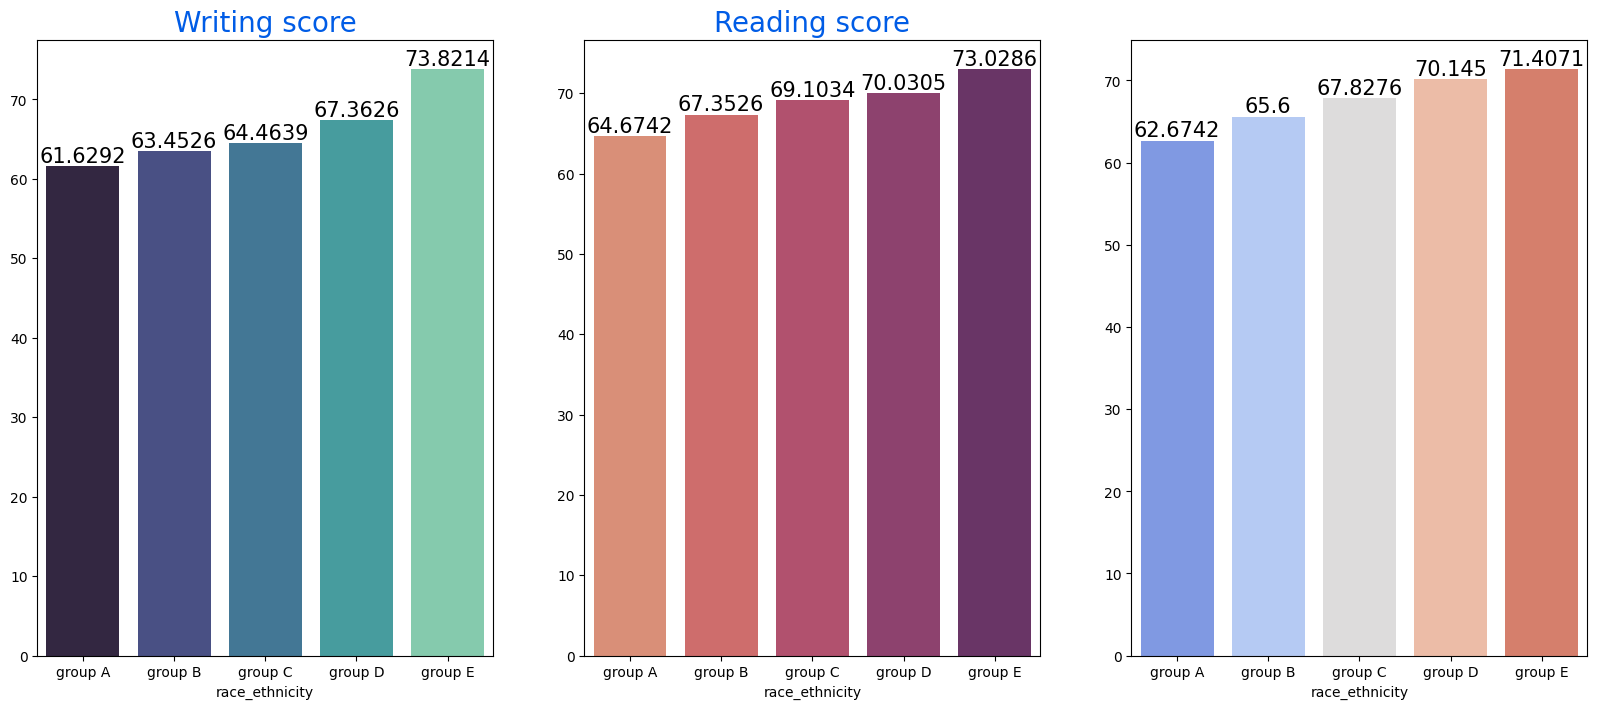

In [62]:
group_data = df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=group_data['math_score'].mean().index, y = group_data['math_score'].mean().values, palette = 'mako', ax=ax[0])
ax[0].set_title('Math score', color = '#005ce6', size = 20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size = 15)

sns.barplot(x=group_data['reading_score'].mean().index, y = group_data['reading_score'].mean().values, palette = 'flare', ax=ax[1])
ax[1].set_title('Reading score', color = '#005ce6', size = 20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size = 15)

sns.barplot(x=group_data['writing_score'].mean().index, y = group_data['writing_score'].mean().values, palette = 'coolwarm', ax=ax[2])
ax[0].set_title('Writing score', color = '#005ce6', size = 20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size = 15)

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

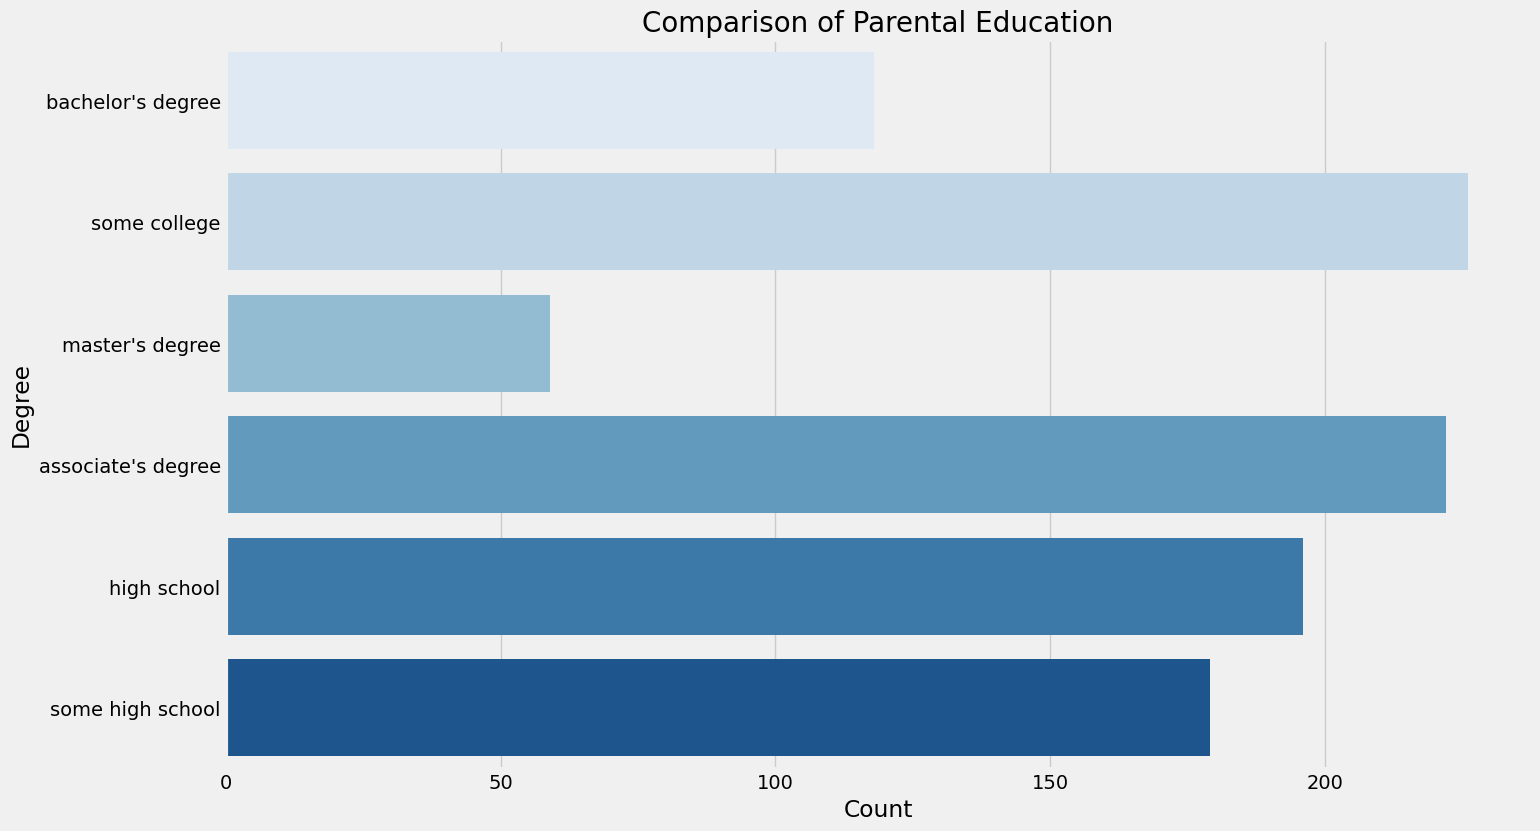

In [64]:
plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette='Blues')
plt.title('Comparison of Parental Education', fontweight = 30,fontsize = 20)
plt.xlabel("Count")
plt.ylabel("Degree")
plt.show()

#### Insights 
- Largest number of parents are from some college.

In [65]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


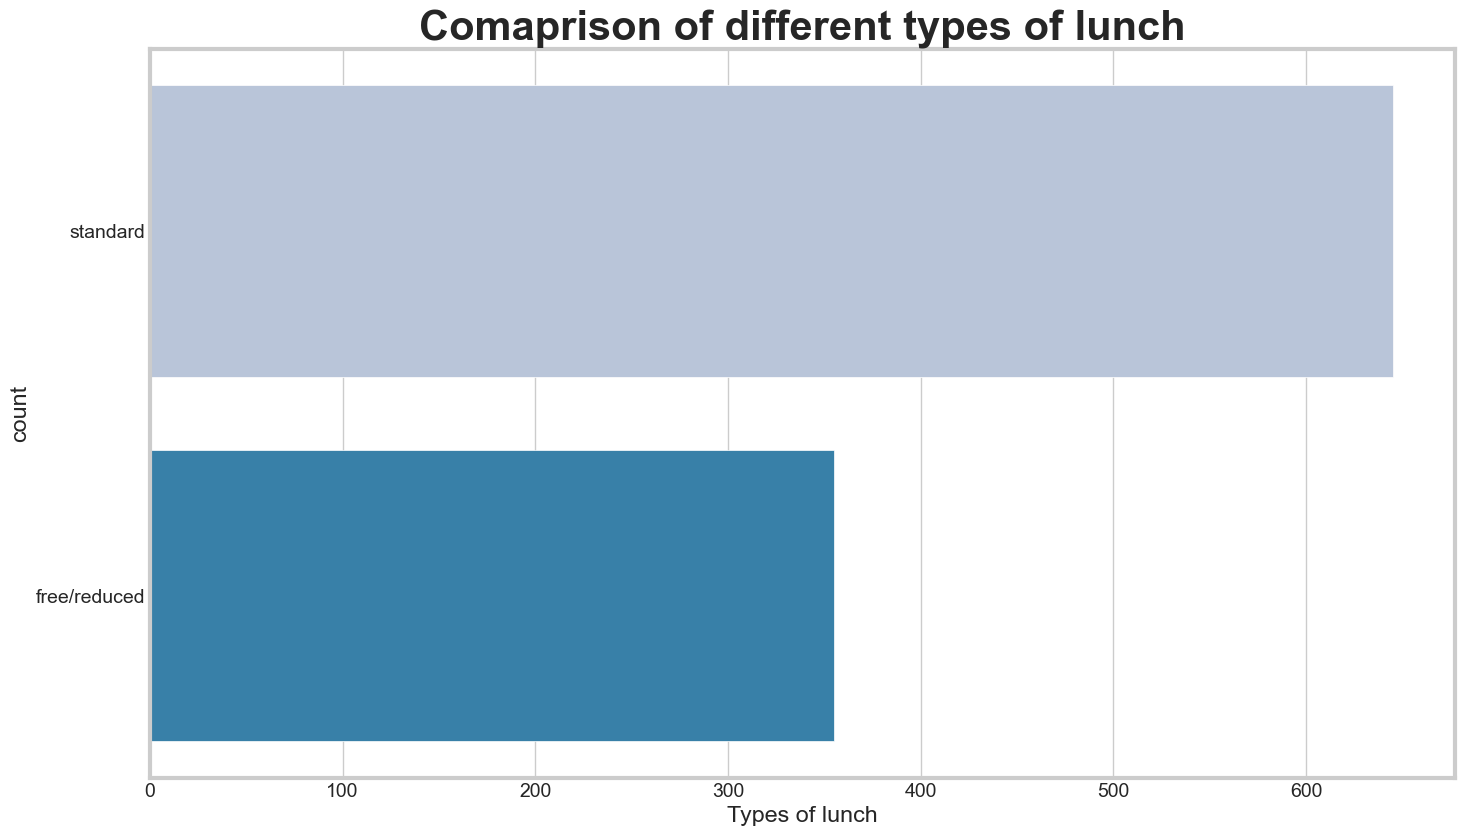

In [69]:
plt.rcParams['figure.figsize'] = (15,9)
sns.set_style("whitegrid")
sns.countplot(df['lunch'], palette='PuBu')
plt.title("Comaprison of different types of lunch", fontweight = 'bold', fontsize = 30)
plt.xlabel("Types of lunch")
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

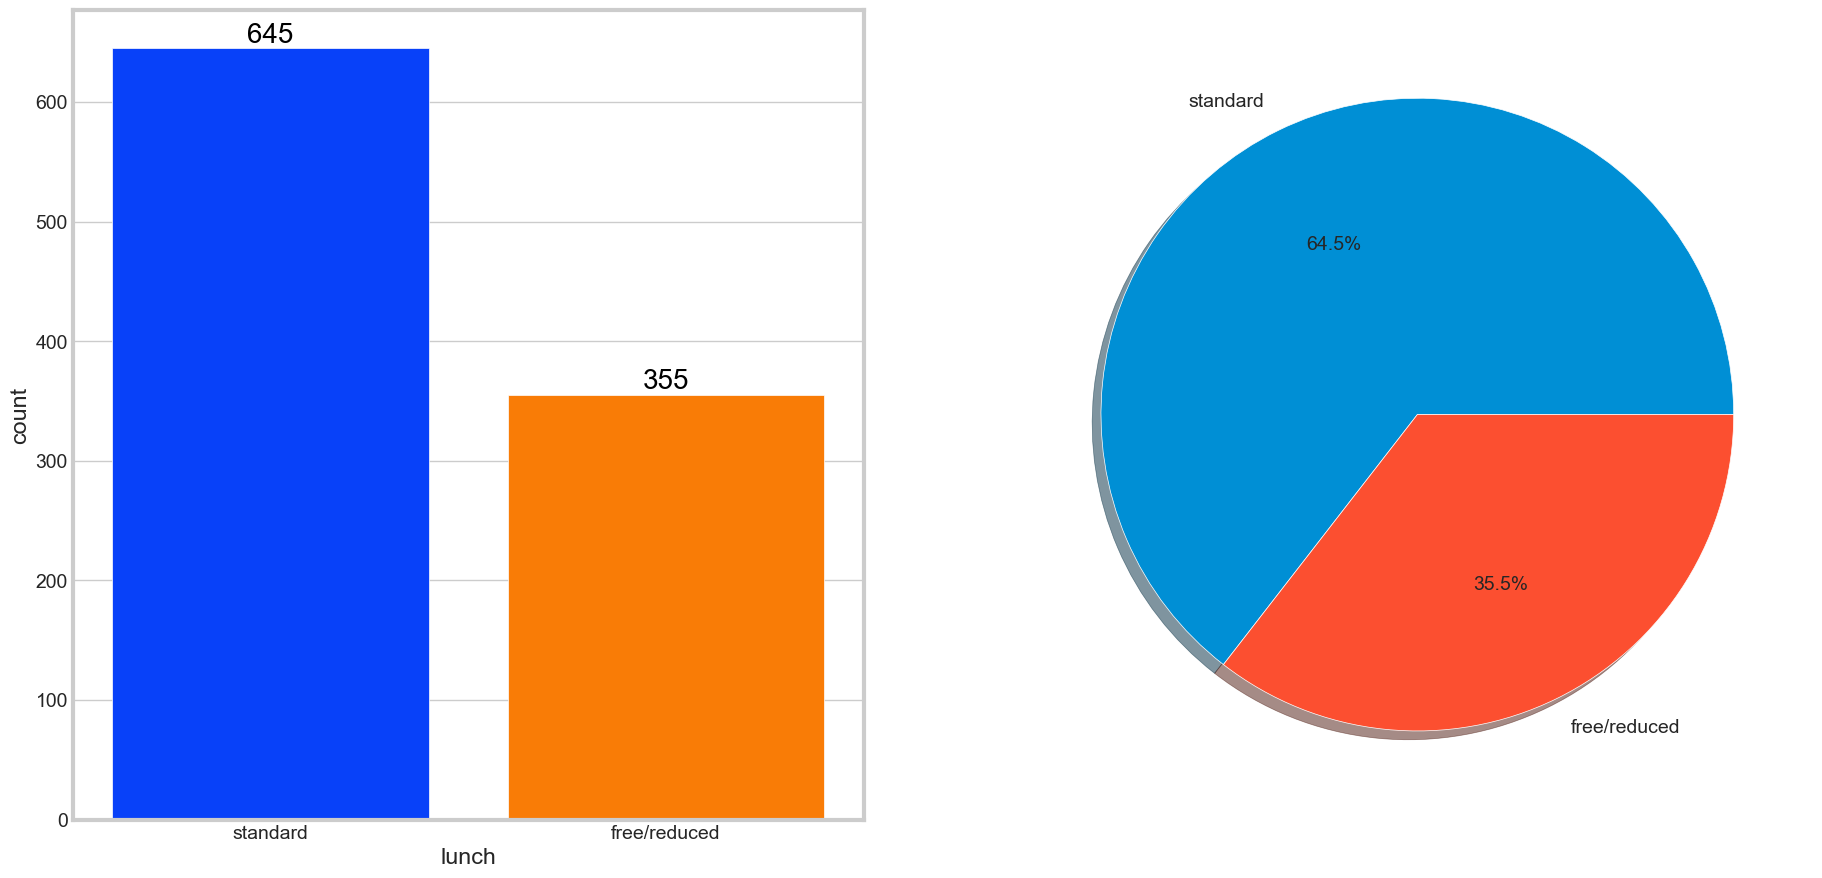

In [71]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['lunch'],data=df,palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['lunch'].value_counts(),labels=df['lunch'].value_counts().index,explode=[0,0],autopct='%1.1f%%',shadow=True)
plt.show()

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

In [72]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


<Axes: xlabel='lunch', ylabel='writing_score'>

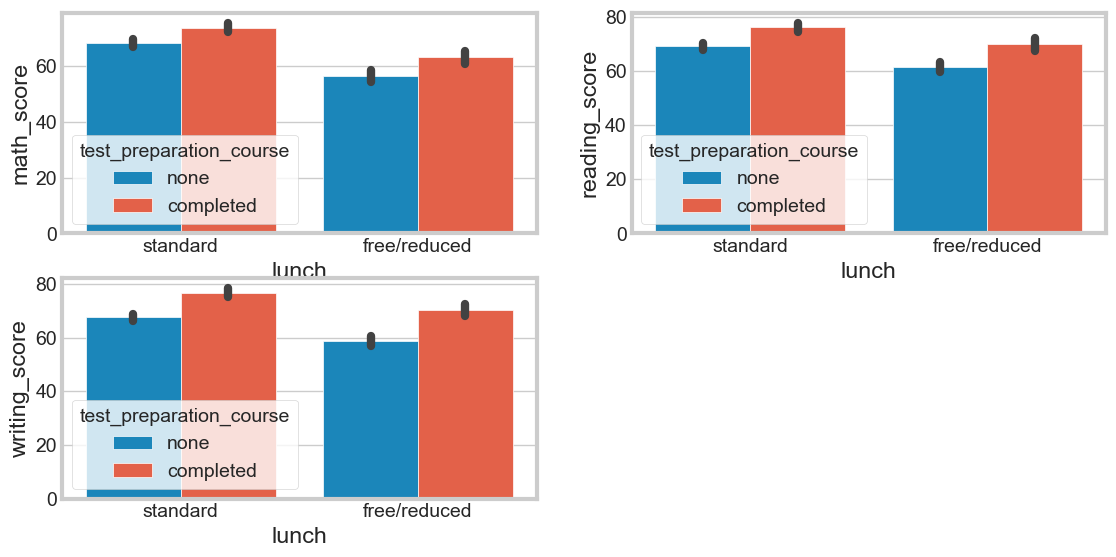

In [74]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot(x=df['lunch'], y=df['math_score'], hue = df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot(x=df['lunch'], y=df['reading_score'], hue = df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot(x=df['lunch'], y=df['writing_score'], hue = df['test_preparation_course'])



#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

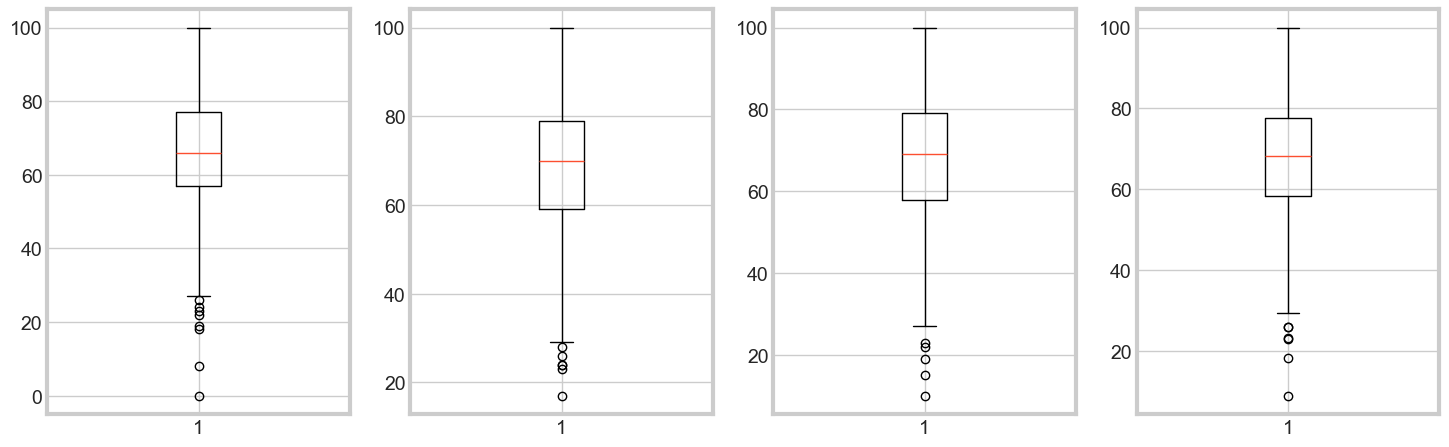

In [82]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
plt.boxplot(df['math_score'])
plt.subplot(142)
plt.boxplot(df['reading_score'])
plt.subplot(143)
plt.boxplot(df['writing_score'])
plt.subplot(144)
plt.boxplot(df['Average'])
plt.show()

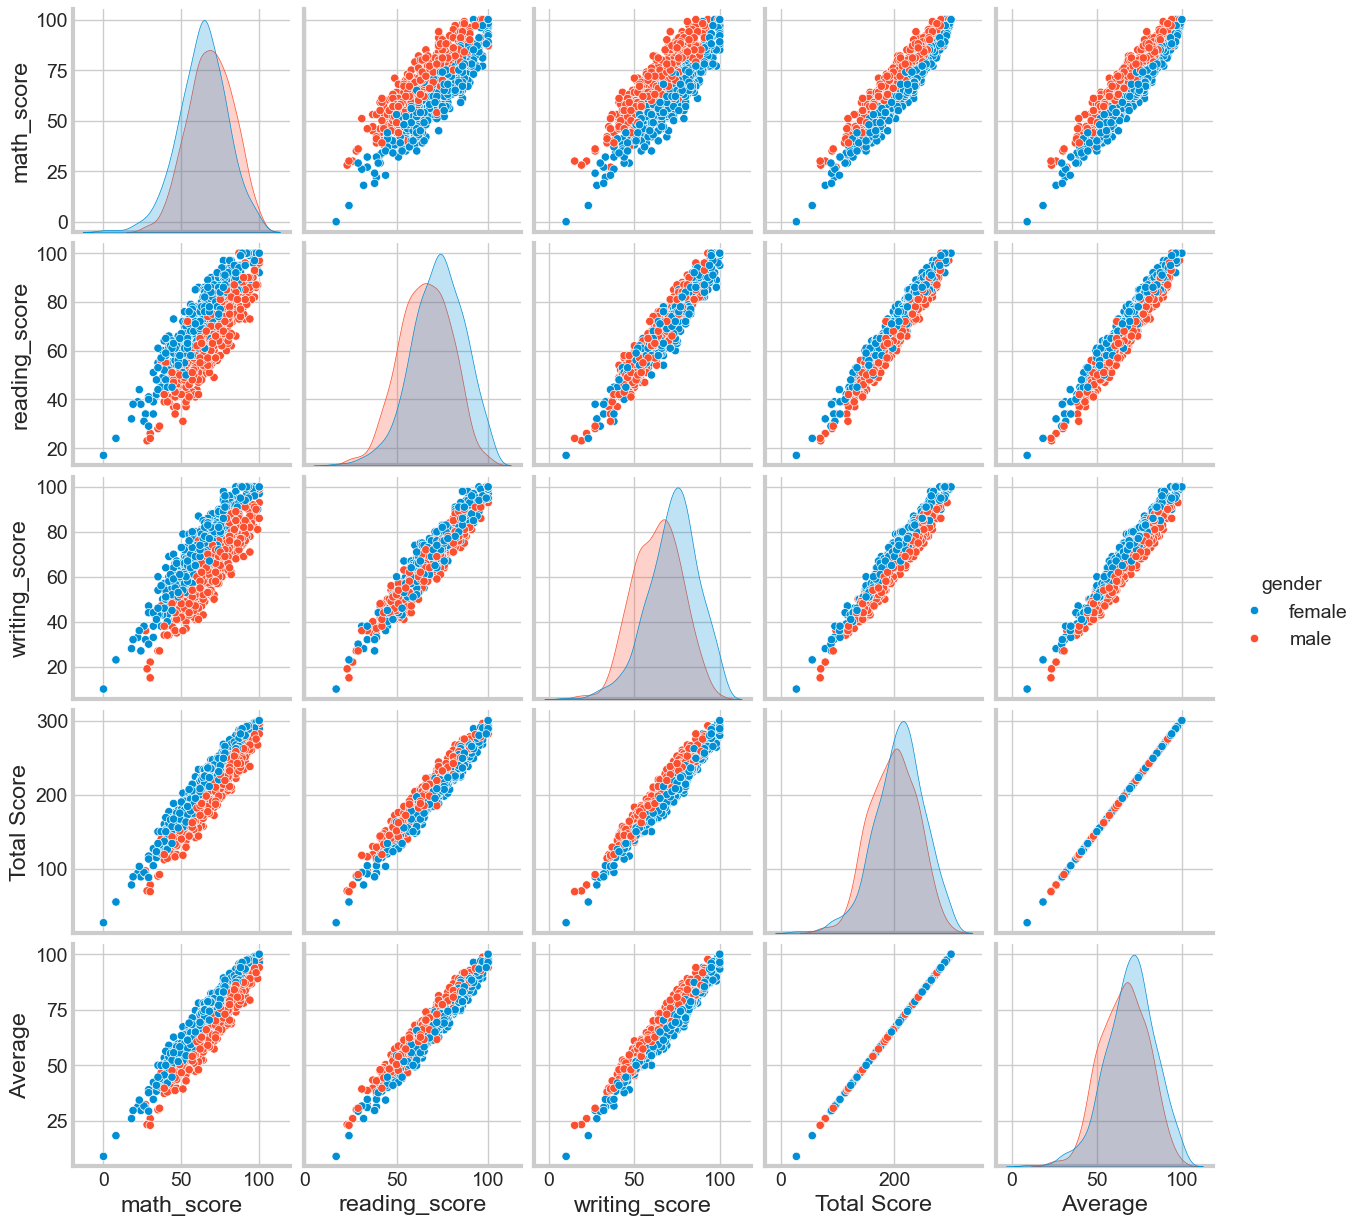

In [83]:
sns.pairplot(df, hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.